In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import logging

import numpy as np
from matplotlib import pyplot as plt

from funbin.einstein.vectorized import aperiodic_monotile_raw
from funbin.geometry import Box, Point, SpatialIndex, all_rotated, as_line_collection, as_poly_collection

logging.basicConfig(level=logging.INFO)

In [3]:
tiling = aperiodic_monotile_raw(niter=2).H7.as_polygons()
angle = np.pi / 4
tiling_rot = all_rotated(tiling, angle)

index = SpatialIndex.from_polygons(tiling_rot)

index_rot = SpatialIndex.from_polygons(tiling)
index_rot._rotation_angle = angle

box_rot = Box.bounding_all(tiling_rot).resized(1.1)

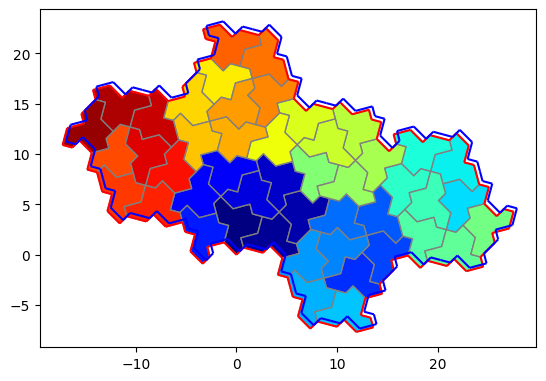

In [4]:
fig, ax = plt.subplots()
ax.add_collection(as_poly_collection(tiling_rot, coloring="sequential"))
ax.add_collection(as_line_collection(index_rot.border_edges, colors="red"))
offset = Point(1.0, 1.0) / 3
offsetted_index_edges = [(start + offset, end + offset) for start, end in index.border_edges]
ax.add_collection(as_line_collection(offsetted_index_edges, colors="blue"))
box_rot.fit_axes(ax)
ax.set_aspect("equal")

In [5]:
def is_ok(point: Point):
    a = list(index.lookup_all_tile_ids(point))
    b = list(index_rot.lookup_all_tile_ids(point))
    return (a, b) if a != b else None

In [6]:
x_grid = np.linspace(box_rot.anchor.x, box_rot.upper_right.x, 100)
y_grid = np.linspace(box_rot.anchor.y, box_rot.upper_right.y, 100)

for x in x_grid:
    for y in y_grid:
        point = Point(x, y)
        if different := is_ok(point):
            print(x, y, *different)

INFO:funbin.geometry:Rectanglizing 47 tiles into 5 x 5 = (5, 5) bins
INFO:funbin.geometry:Indexing tiles
INFO:funbin.geometry:Computing border edges...
INFO:funbin.geometry:Computed border edges: 128
DEBUG:funbin.geometry:Rotating to angle: 5.454944073009738
DEBUG:funbin.geometry:Bbox computed: Box((-8.18, -27.70), w=31.08, h=44.49)
DEBUG:funbin.geometry:Chosen rect center inside the tiling: (18.57, 0.49)
DEBUG:funbin.geometry:Rect side after binary search: 2.3382785616655415
DEBUG:funbin.geometry:Rotating to angle: 1.3087878412210834
DEBUG:funbin.geometry:Bbox computed: Box((-20.85, -3.10), w=43.02, h=24.49)
DEBUG:funbin.geometry:Chosen rect center inside the tiling: (8.66, 15.44)
DEBUG:funbin.geometry:Rect side after binary search: 2.0796360878469677
DEBUG:funbin.geometry:Rotating to angle: 1.4401197725082147
DEBUG:funbin.geometry:Bbox computed: Box((-21.27, -4.59), w=41.45, h=27.49)
DEBUG:funbin.geometry:Chosen rect center inside the tiling: (7.79, 5.56)
DEBUG:funbin.geometry:Rect s

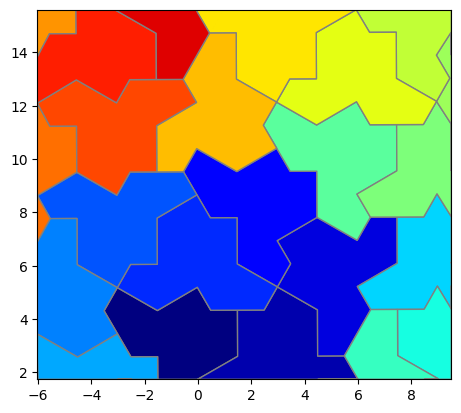

In [25]:
from funbin.geometry import logger, rectanglize_tiling

logger.setLevel(logging.DEBUG)

fig, ax = plt.subplots()
tiling_rect = rectanglize_tiling(tiles=tiling, target_bins=(5, 5))
ax.add_collection(as_poly_collection(tiling_rect, coloring="sequential"))
Box.bounding_all(tiling_rect).fit_axes(ax)
ax.set_aspect("equal")